In [ ]:
# A basic use of montecarlo.py and trade.py
# Goes long if a stock has been growing beyond some threshold over given time periods

In [1]:
import os
import pandas as pd
from datetime import datetime
from tools.scraper import *
from tools.montecarlo import *
from tools.trade import *
import matplotlib.pyplot as plt

In [2]:
data_dir = f"data/{os.listdir("data")[-1]}" # most recent scrape
# comp_dict = get_companies_dict()

In [3]:
# (x,y)
# After x days, returns must be at least y%
periods = [ 
    (30, 0.05),
    (90, 0.078),
    (180, 0.122),
    (270, 0.191),
    (360, 0.3)
]

In [4]:
# Check tools.trade for a specification of judge
def judge(df: pd.DataFrame) -> None | Trade:
    if len(df) >= 361 and all([df["gain"].iloc[period] > gain for (period, gain) in periods]):
        return Trade(
            "N/A",
            df.iloc[0]["date"],
            "Long",
            (df.iloc[0]["open"]+df.iloc[0]["close"])/2,
            0.05,
            0.05,
            0.05
        )
    else:
        return None

In [5]:
def clean_df(df: pd.DataFrame, cik: str):
    df = pd.read_csv(f"{data_dir}/{cik}/ohclv.csv")
    df = df.iloc[::-1].reset_index(drop=True) # df[0] is now the most recent date
    df.columns = map(str.lower, df.columns)
    df["gain"] = (df.iloc[0]["close"]-df["close"])/df["close"] # Percentage gain from that day to the last day 
    return df

In [6]:
all_trades = []
i = 0
for cik in os.listdir(data_dir):
    if (i%100 == 0):
        print(i, len(all_trades))
        if (i==200):
            break
    if os.path.exists(f"{data_dir}/{cik}/ohclv.csv"):
        ohclv = pd.read_csv(f"{data_dir}/{cik}/ohclv.csv")
        # ohclv = clean_df(ohclv, cik)[len(ohclv)-3650:] # take data 10 years after start
        ohclv = clean_df(ohclv, cik)[:3650] # past 10 years
        tr = get_trades(ohclv, judge)
        all_trades.extend(tr)
        if len(tr) != 0:
            last = ohclv
            ohclv = ohclv.iloc[::-1].reset_index(drop=True)
            ohclv = ohclv[len(ohclv)-500:]
    i += 1


0 0
100 7774
200 15395


Max drawdown: -7.069847984216398%
Worst performance: 21.25080966182115%
Avg. adj. gain per trade: 0.030383241312114583%
Winrate: 56.076648262422864%
Average performance: 60.4360928611988%


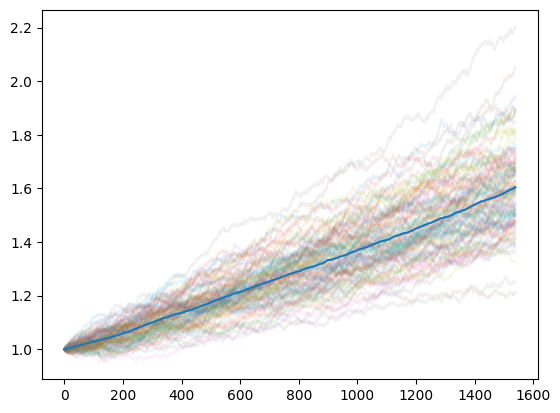

In [8]:
MonteCarlo(all_trades, 0.1, False).show(100)